In [1]:
# Si estás en Google Colab o en un entorno donde PennyLane o networkx no están instalados, puedes usar los siguientes comandos para instalarlos:

!pip install pennylane
!pip install networkx

# Sesión 12 Laboratorio de Computación Cuántica 2

## Formulación QUBO, Algoritmo QAOA y Annealing para problemas combinatorios

Ya que sabemos lo que es un Hamiltoniano, vamos a introducir a los conceptos necesarios para usar las herramientas que el VQE nos introdujo para trabajar con optimización de problemas combinatorios con aplicaciones en el mundo real.

## Clases de complejidad computacional

En teoría de la complejidad, los problemas se clasifican según qué tan difícil es resolverlos y verificarlos.

### Problemas $P$

Son los problemas que pueden resolverse eficientemente por una computadora clásica, es decir, en tiempo polinomial.

Si el tiempo de ejecución crece como

$$
n,\quad n^2,\quad n^3,\quad \dots
$$

entonces el problema pertenece a la clase $P$.

Ejemplos:
- Ordenar una lista
- Encontrar el camino más corto en un grafo
- Multiplicar matrices


### Problemas $NP$

Los problemas $NP$ son aquellos donde una solución propuesta puede verificarse eficientemente, aunque encontrarla pueda ser difícil.

Es decir:
- Encontrar la solución puede ser complicado.
- Verificar que una solución es correcta es rápido.

Ejemplo:
- Sudoku
- Traveling Salesman Problem (versión de decisión)
- Coloración de grafos


### Problemas NP-Hard

Un problema es **NP-Hard** si es al menos tan difícil como los problemas más difíciles de $NP$.

No necesariamente puede verificarse eficientemente ni siquiera pertenecer a $NP$.

Intuitivamente:
- Si resolvemos un problema NP-Hard eficientemente, podríamos resolver todos los problemas de $NP$ eficientemente.

Ejemplos:
- Traveling Salesman Problem
- Muchos problemas de optimización combinatoria


### Problemas NP-Complete

Son los problemas que cumplen dos condiciones:

1. Pertenecen a $NP$
2. También son NP-Hard

Es decir, son los problemas más difíciles dentro de $NP$.

Si algún problema NP-Complete pudiera resolverse en tiempo polinomial, entonces:

$$P = NP$$

Lo cual es uno de los problemas del milenio

Ejemplos clásicos:
- SAT
- 3-SAT
- Vertex Cover
- Coloración de grafos
- Hamiltonian Cycle


### Relación entre clases

$$
P \subseteq NP
$$

y dentro de $NP$ se encuentran los problemas NP-Complete.

Los problemas NP-Hard pueden incluso estar fuera de $NP$.

## Problemas Combinatorios



La rama de la matemática combinatoria nos presenta diversos desafíos interesantes con aplicaciones en el mundo real. Aquí presentare diversos problemas combinatorios y como entenderos y abordarlos para posteriormente, con la ayuda de la computación cuántica, encontrar formas de tajarlos.

## Teoría de Grafos (Introducción a Networkx)

Un grafo es una estructura matemática conformada por un conjunto de nodos (o vertices) y conexiones entre ellos llamadas aristas. Es un modelo muy sencillo, pero a partir de este modelo se derivan UNA INFINIDAD de problemas relacionados a optimización

Estos permiten representar relaciones y redes, por lo que son una herramienta fundamental para modelar sistemas con aplicaciones reales. 

Aquí veremos 4 problemas principales que se pueden abordar con esto:

1. Problema de Coloración
2. Max-cut
3. Traveling Salesman/Problema del Viajero
4. Knapsack Problem/Contenido de la mochila

Los 3 primeros son problemas relacionados a Teoría de Grafos, de modo que para poder abordarlos, daremos una introducción intuitiva a los mismos utilizando la librería Networkx

Crearemos un grafo simple:

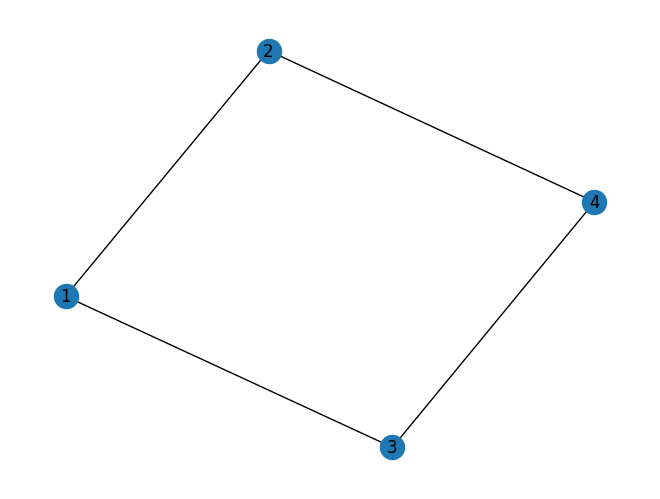

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()   #Fabricamos el espacio de grafos

# Agregamos nodos
G.add_nodes_from([1, 2, 3, 4])

# Agregamos conexiones
G.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4)
])

nx.draw(G, with_labels=True)  #Dibujamos el grafo
plt.show()

In [ ]:
print(G.nodes()) #Imprime los nodos del grafo
print(G.edges()) #Imprime las conexiones del grafo
print(list(G.neighbors(1))) #Imprime los vecinos del nodo 1, es decir, los nodos conectados a él

[1, 2, 3, 4]
[(1, 2), (1, 3), (2, 4), (3, 4)]
[2, 3]


### Problema de Coloración de Grafos

Imagina que te dan un grafo y te dicen "Vas a colorear cada uno de los nodos" de manera que no hayan 2 nodos conectados que tengan el mismo color. La pregunta es ¿Cuantos colores necesitas para poder colorear a este grafo? El número mínimo de colores que necesitas se le conoce como el número cromático. 

Este es un problema NP-Hard